# Activation Functions and Multilayer Perceptrons (MLP)
---
## Motivation

Understanding activation functions and Multilayer Perceptrons (MLPs) is fundamental to modern machine learning.  
While linear models are limited to learning affine relationships, neural networks extend this framework by composing affine transformations with nonlinear activation functions.

This notebook connects:

- Activation functions (Sigmoid and ReLU)
- Multilayer Perceptrons as composed functions
- Gradient flow (vanishing and exploding effects)
- Function approximation and geometric interpretation
- Convergence behavior during training

---

## Step 1 — Machine Learning as Function Approximation

At a fundamental level, a machine learning model can be interpreted as a parametric function that maps inputs to outputs:

$$
\hat{y} = f(x; \theta)
$$

Where:
- $x$ is the input vector
- $\theta$ represents the model parameters (weights and biases)
- $\hat{y}$ is the predicted output

In this notebook, the input consists of two features $(x_1, x_2)$, and the model learns a continuous output by approximating an underlying functional relationship present in the data.

---

## Step 2 — Limitation of Purely Linear Models

A single-layer linear model learns a function of the form:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + b
$$

This is an affine transformation.

Geometrically, it produces a plane in the feature space.  
Such a model can scale and rotate the input space, but it cannot represent curved or nonlinear relationships, regardless of how well the parameters are optimized.

This limitation motivates the use of neural networks, which increase model capacity through nonlinearity and function composition.

---

## Step 3 — Multilayer Perceptron as a Composed Function

A Multilayer Perceptron (MLP) is constructed by stacking affine transformations and activation functions.  
For a one-hidden-layer MLP, the forward pass is:

$$
z_1 = X W_1 + b_1
$$

$$
a_1 = \phi(z_1)
$$

$$
z_2 = a_1 W_2 + b_2
$$

Where:
- $z_1$ is the affine transformation of the inputs
- $a_1$ is the activated hidden representation
- $z_2$ is the final prediction

From a machine learning perspective, this architecture represents a composition of functions:

$$
f(x) = f_2(f_1(x))
$$

This composition allows the network to learn richer and more flexible mappings than a single linear transformation.

---

## Step 4 — Role of Activation Functions and Gradient Dynamics

### Why Activation Functions Are Necessary

Activation functions introduce nonlinearity into the network.  
Without them, stacking multiple layers would still result in a single affine transformation.

Consider a network without activation:

$$
z_1 = X W_1 + b_1
$$

$$
z_2 = z_1 W_2 + b_2
$$

Substituting:

$$
z_2 = (X W_1 + b_1) W_2 + b_2 = X W_1 W_2 + b_1 W_2 + b_2
$$

This remains an affine function of the input.  
The activation function breaks this linear collapse by applying a nonlinear transformation:

$$
a_1 = \phi(z_1)
$$

---

### Sigmoid Activation

The sigmoid activation is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

It transforms any real-valued input into the interval $(0, 1)$, which made it particularly suitable for probabilistic interpretations and for use in early neural network architectures.

However, sigmoid suffers from saturation. For large positive or negative inputs, the function becomes nearly flat:

$$
\frac{d\sigma(z)}{dz} \approx 0
$$

During backpropagation, gradients are propagated using the chain rule. When derivatives are consistently small, the gradient magnitude shrinks exponentially across layers. This leads to the vanishing gradient problem.

Consequences include:
- Very slow learning in early layers
- Difficulty training deeper networks
- Weak parameter updates

---

### ReLU Activation

The Rectified Linear Unit (ReLU) is defined as:

$$
\text{ReLU}(z) = \max(0, z)
$$

Its derivative is:

$$
\frac{d}{dz}\text{ReLU}(z) =
\begin{cases}
1, & z > 0 \\
0, & z \le 0
\end{cases}
$$

This piecewise-linear behavior has important implications for optimization.

In the active region ($z > 0$), the derivative equals 1, meaning the activation function does not attenuate gradient magnitudes during backpropagation.  
This improves gradient flow across layers and enables faster and more stable training compared to saturating activations like sigmoid.

From a geometric perspective, ReLU allows the network to build piecewise-linear approximations of complex functions, bending the prediction surface without compressing intermediate representations.

---

### Vanishing and Exploding Gradients

Gradient propagation in neural networks depends on repeated multiplication of weight matrices and activation derivatives:

$$
\frac{\partial \mathcal{L}}{\partial W_1}
\propto
\frac{\partial \mathcal{L}}{\partial z_L}
\prod_{l=1}^{L-1} \left( W_l^\top \cdot \phi'(z_l) \right)
$$

If the terms in this product are:
- Smaller than 1 → gradients vanish
- Larger than 1 → gradients explode

With sigmoid, derivatives are bounded and often very small in saturated regions, making vanishing gradients more likely.  
With ReLU, gradients are preserved in the active region, reducing attenuation but introducing the possibility of inactive neurons when $z \le 0$ (zero gradient). Thus, activation choice directly affects training stability, convergence speed, and the ability of the network to learn deep representations.

---

## Step 5 — Example: Function Approximation, Geometry, and Convergence

In this example, we will use a Multilayer Perceptron (MLP) to approximate an unknown function that maps two input features $(x_1, x_2)$ to a continuous output $y$.

Formally, the model learns:

$$
\hat{y} = f(x_1, x_2; W_1, b_1, W_2, b_2)
$$

Where the parameters are optimized to minimize the prediction error over the dataset.  
From an ML perspective, this corresponds to learning a smooth functional mapping over the input space rather than simply fitting individual data points.

After training the MLP, we will perform a geometric interpretation of the learned function by evaluating the network over a meshgrid spanning the input domain $(x_1, x_2)$.  
This allows us to visualize the prediction surface and understand how nonlinear activations bend the learned function compared to a linear model.

Finally, we will analyze the convergence behavior during training by observing how the loss evolves across epochs.  
This connects gradient-based optimization with function learning, showing how parameter updates progressively refine the prediction surface until the model stabilizes in a low-loss region.

In [17]:
import numpy as np
from typing import Callable
import matplotlib.pyplot as plt
from numpy.typing import ArrayLike

rng = np.random.default_rng(42)

def ReLU(arr: ArrayLike):
    return np.maximum(0, arr)

def linear(arr: ArrayLike):
    return arr

def layer(W: ArrayLike, x: ArrayLike, b: ArrayLike, act_func: Callable):
    return act_func((x @ W.T) + b)

def multylayer_perceptron(X, w1, b1, w2, b2):
    z1 = layer(w1, X, b1, linear)
    a1 = ReLU(z1)
    z2 = layer(w2, a1, b2, linear)
    return z1, a1, z2

def half_mean_squared_error(y_true, y_pred): return np.mean(((y_pred - y_true) ** 2)) / 2

def gradient(y_true, z1, a1, z2, w2, x):
    delta2 = (z2 - y_true) / y_true.shape[0]
    dL_dw2 = delta2.T @ a1
    dL_db2 = delta2.sum(axis=0, keepdims=True)
    
    delta1 = (delta2 @ w2) * (z1 > 0)
    dL_dw1 = delta1.T @ X
    dL_db1 = delta1.sum(axis=0, keepdims=True)

    return dL_dw1, dL_db1, dL_dw2, dL_db2

def train_2_layers_mlp(X, y, hidden_dim, epochs=50, learning_rate=0.05):
    features_dim = X.shape[1]

    w1 = rng.normal(loc=0, scale=1, size=(hidden_dim, features_dim))
    b1 = np.zeros(shape=(1, hidden_dim))

    w2 = rng.normal(loc=0, scale=1, size=(1, hidden_dim))
    b2 = np.zeros(shape=(1, 1))

    losses = []

    for e in range(epochs):
        z1, a1, z2 = multylayer_perceptron(X, w1, b1, w2, b2)
        loss = half_mean_squared_error(y, z2)
        dL_dw1, dL_db1, dL_dw2, dL_db2 = gradient(y, z1, a1, z2, w2, X)

        losses.append(loss)

        w1 -= dL_dw1*learning_rate
        b1 -= dL_db1*learning_rate
        
        w2 -= dL_dw2*learning_rate
        b2 -= dL_db2*learning_rate
        
    return w1, b1, w2, b2, losses

def generate_data(features_dim, batch_size=200, noise_std=0.1, seed=42):
    X = rng.normal(0, 1, size=(batch_size, features_dim))
    w_true = rng.normal(0, 2, size=(features_dim, 1))
    b_true = rng.normal(0, 1)

    noise = rng.normal(0, noise_std, size=(batch_size, 1))
    y = X @ w_true + b_true + noise

    return X, y, w_true, b_true

hidden_dim = 5
features_dim = 2
batch_size = 100

X, y_true, w_true, b_true = generate_data(features_dim, batch_size)
w1, b1, w2, b2, losses = train_2_layers_mlp(X, y_true, hidden_dim, 100)

        

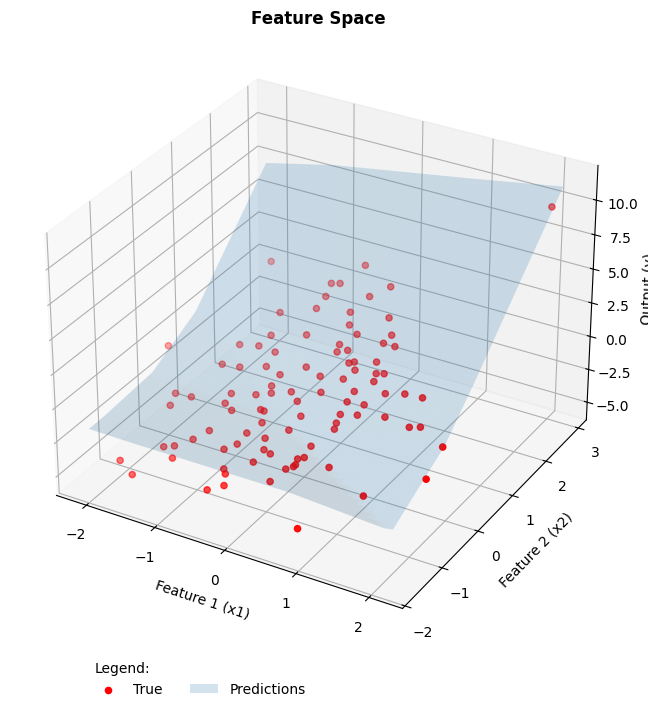

In [22]:
x1_grid, x2_grid = np.meshgrid(
    np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), batch_size),
    np.linspace(np.min(X[:, 1]), np.max(X[:, 1]), batch_size)
)

X_grid = np.column_stack([
    x1_grid.ravel(),
    x2_grid.ravel()
])

z1, a1, z2 = multylayer_perceptron(X_grid, w1, b1, w2, b2)
z2_surface = z2.reshape(x1_grid.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], y_true.flatten(), color='red', label='True')
ax.plot_surface(x1_grid, x2_grid, z2_surface, alpha=0.2, label='Predictions')

ax.legend(bbox_to_anchor=(.5, -.1), ncol=2, title='Legend:', frameon=False, loc='lower right', alignment='left')
plt.title("Feature Space", fontweight='bold')
ax.set_xlabel("Feature 1 (x1)")
ax.set_ylabel("Feature 2 (x2)")
ax.set_zlabel("Output (y)")
plt.show()

## Effect of the Learning Rate on Loss Dynamics

The comparison between a small learning rate (0.05) and a large learning rate (0.5) highlights an important optimization phenomenon in neural networks: the trade-off between stability and speed of convergence.

With the smaller learning rate, the loss decreases smoothly and monotonically across epochs. This indicates that each parameter update is relatively small, allowing the model to follow a stable descent direction in the loss landscape. Mathematically, gradient descent updates the parameters as:
$$
\theta_{t+1} = \theta_t - \eta \nabla \mathcal{L}(\theta_t)
$$
where $\eta$ is the learning rate. When $\eta$ is small, the step size in parameter space is controlled, reducing the risk of overshooting the minimum.

In contrast, when the learning rate is increased to 0.5, the loss exhibits an initial explosion and strong oscillations before stabilizing. This occurs because the update magnitude becomes large:
$$
\|\Delta \theta\| \propto \eta \|\nabla \mathcal{L}\|
$$
A large learning rate amplifies the gradient signal, causing the optimizer to overshoot the local minimum repeatedly. Instead of moving directly toward the basin of the minimum, the parameters bounce across the curvature of the loss surface, producing sharp spikes and instability in the loss trajectory.

From a geometric perspective, the optimization path with a high learning rate does not follow a smooth descent curve. Instead, it zigzags across the loss landscape, especially in regions with high curvature. This behavior is often interpreted as a form of “loss explosion” at the beginning of training, not because gradients themselves diverge, but because the parameter updates are too aggressive relative to the local geometry of the objective function.

The attenuation of the oscillations over time can be explained by two interacting factors. First, as training progresses, the model approaches flatter regions of the loss surface where gradients naturally become smaller:
$$
\|\nabla \mathcal{L}(\theta)\| \downarrow \quad \text{as} \quad \theta \to \theta^*
$$
Even with a large learning rate, smaller gradients reduce the effective step size, stabilizing the updates.

Second, the curvature near a minimum typically leads to corrective gradient directions. Large oscillatory steps gradually lose energy because successive updates partially cancel each other out as the model repeatedly crosses the minimum. This results in a damped oscillation pattern in the loss curve, where instability is strongest at early epochs and progressively decreases.

In the context of MLP training, this behavior reflects the interaction between learning rate, gradient magnitude, and the curvature induced by activation functions and weight matrices. A higher learning rate accelerates early learning but increases the risk of instability, while the natural reduction in gradient magnitude near convergence attenuates the initial explosion and allows the model to eventually settle into a low-loss region.

Text(0, 0.5, 'Loss')

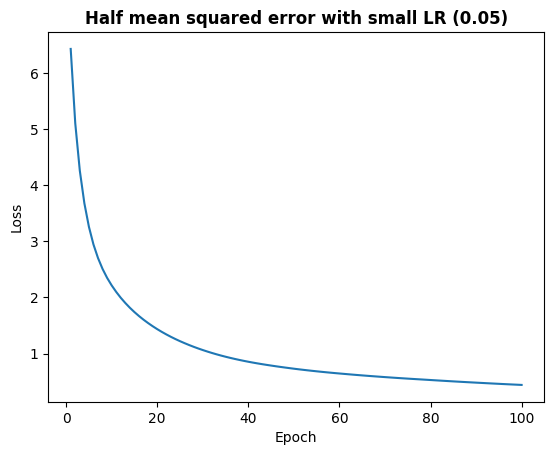

In [19]:

plt.plot(np.array(range(len(losses)))  + 1, losses)
plt.title('Half mean squared error with small LR (0.05)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')


In [20]:

w1, b1, w2, b2, losses = train_2_layers_mlp(X, y_true, features_dim, hidden_dim, 100, .5)


plt.plot(np.array(range(len(losses)))  + 1, losses)
plt.title('Half mean squared error with big LR (0.5)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')


TypeError: train_2_layers_mlp() takes from 3 to 5 positional arguments but 6 were given

In [ ]:
X.shape

(100, 2)

In [ ]:
np.subtract(z2, y)

ValueError: operands could not be broadcast together with shapes (10000,1) (100,1) 